In [1]:
from pathlib import Path

import pandas as pd

DATASET_DIR = Path("dataset")

# Покупатели
customers = pd.read_csv(DATASET_DIR / "olist_customers_dataset.csv")
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [2]:
customers.describe(include="all")

# чем отличаются customer_id и customer_unique_id? если убрать customer_id, будут ли строки с одинаковым customer_unique_id дубликатами?
# Ответ: customer_id — идентификатор покупателя в рамках конкретного заказа;
# через него orders соединяется с customers. customer_unique_id объединяет
# разные заказы одного реального покупателя и подходит для его истории покупок.
# В данных 99 441 customer_id и 96 096 customer_unique_id; у 2 997 покупателей
# несколько customer_id. Совпадение customer_unique_id не означает дубль строки:
# у 252 покупателей различаются адресные поля. После удаления customer_id
# customers.drop(columns="customer_id").duplicated().sum() даёт 3 089
# лишних полных совпадений оставшихся полей. Это не дубликаты заказов:
# разные покупки одного человека с тем же адресом нужно сохранить.
# customer_id нужен до присоединения customer_unique_id к заказам.

# customer_state имеет и числовые и символьные значения, надо привести к одному
# Ответ: в исходном столбце только 27 буквенных кодов штатов/федерального округа
# (SP, RJ, MG и др.), числовых значений нет. В describe числа count, unique
# и freq — статистики, а top — самое частое значение столбца, здесь SP.
# NaN в строках mean/std для строкового столбца означает неприменимую
# статистику, а не пропуски исходных данных. Приведение смешанных типов
# не требуется: customer_state уже строковый категориальный признак.
# Проверка: customers["customer_state"].value_counts(dropna=False)
#__________________________________________________
# Нужно добавить эти признаки в датасет

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [3]:
# Геолокация
geolocation = pd.read_csv(DATASET_DIR / "olist_geolocation_dataset.csv")
geolocation.describe(include="all")
# geolocation_zip_code_prefix надо измнить формат, кажется это категориальная переменная 
# Ответ: да, это первые пять цифр почтового индекса — код территории,
# а не числовая величина. Среднее и расстояние между такими кодами бессмысленны.
# Лучше читать как строку, чтобы сохранить ведущие нули (например, 01037):
# geolocation = pd.read_csv(
#     DATASET_DIR / "olist_geolocation_dataset.csv",
#     dtype={"geolocation_zip_code_prefix": "string"},
# )
# Для уже загруженного int-столбца: .astype("string").str.zfill(5).
# Тот же формат нужен у customer_zip_code_prefix и seller_zip_code_prefix.
# Здесь 19 015 уникальных префиксов на 1 000 163 строки. Перед соединением
# по префиксу нужно агрегировать геолокацию до одной строки на ключ
# (например, медианы координат), иначе строки заказов размножатся.
# Для модели можно использовать координаты/штат; сам индекс — служебный
# ключ или категориальный признак с большим числом значений.
#__________________________________________________

# НУжно добавить в датасет geolocation_lat	geolocation_lng	geolocation_city	geolocation_state для отправителя и для получателя.

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [4]:
# Позиции заказов
order_items = pd.read_csv(DATASET_DIR / "olist_order_items_dataset.csv")
order_items.describe(include="all")

# отличие order_id и order_item_id
# Ответ: order_id идентифицирует весь заказ и ссылается на orders.order_id.
# order_item_id — порядковый номер позиции внутри заказа, начиная с 1.
# Он повторяется в разных заказах; ключ строки — (order_id, order_item_id).
# В таблице 112 650 позиций для 98 666 заказов, составной ключ уникален.
# Один product_id может встречаться в нескольких позициях одного заказа:
# это могут быть несколько единиц товара, а не ошибочные дубликаты.

# на какую таблицу указывает saller_id?
# Ответ: фактическое имя столбца — seller_id. Это ссылка на seller_id
# таблицы sellers из olist_sellers_dataset.csv. Все значения имеют
# соответствие в sellers; соединение: on="seller_id", validate="many_to_one".
#__________________________________________________

# shipping_limit_date не берём в датасет, остальное оставляем

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [5]:
# Платежи
order_payments = pd.read_csv(DATASET_DIR / "olist_order_payments_dataset.csv")
order_payments.describe(include="all")
# эта таблица не интересует для анализа
# Ответ: для текущего baseline её можно не присоединять: историю user–item
# получаем из orders, customers и order_items, а свойства товаров — из products.
# Платежи пригодились бы для анализа способов оплаты, рассрочки и суммы заказа.
# Если они понадобятся позже, сначала нужно агрегировать их по order_id:
# у заказа бывает несколько платежей, и прямой join размножит позиции.

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [6]:
# Отзывы
order_reviews = pd.read_csv(
    DATASET_DIR / "olist_order_reviews_dataset.csv",
    encoding="utf-8", encoding_errors="strict",
)
order_reviews.describe(include="all")

# надо посчитать сколько слов в review_comment_title и review_comment_message в отдельные колонки
# Ответ: для простого подсчёта можно разделять текст по пробельным символам.
# Пример добавления двух колонок (пустой текст/пропуск получает 0):
# for column in ["review_comment_title", "review_comment_message"]:
#     order_reviews[f"{column}_word_count"] = (
#         order_reviews[column].fillna("").str.split().str.len()
#     )
# Это количество фрагментов между пробелами, не лингвистическая токенизация.
# Проверено на CSV: максимум 8 слов в заголовке и 45 в сообщении.
# Пропущено 87 656 заголовков и 58 247 сообщений; исходные текстовые столбцы
# сохраняют пропуски, поэтому отсутствие текста можно отличить от пустой строки.

# ещё надо сопостамить order_id с product_id и посчитать сколько отзыов если на каждый продукт
# Ответ: связь проходит через order_items. Важно: отзыв относится к заказу
# целиком, а не к конкретному товару. Если товаров несколько, один отзыв
# будет связан с каждым из них; это число связанных отзывов о заказах.
# Сначала убираем повторные пары заказ–товар, чтобы несколько единиц одного
# товара не увеличивали счётчик. review_id сам по себе не уникален в CSV;
# считаем уникальные пары (order_id, review_id) для каждого product_id:
# product_orders = order_items[["order_id", "product_id"]].drop_duplicates()
# review_keys = order_reviews[["order_id", "review_id"]].drop_duplicates()
# product_reviews = product_orders.merge(review_keys, on="order_id", how="inner")
# product_review_counts = (
#     product_reviews.drop_duplicates(["product_id", "order_id", "review_id"])
#     .groupby("product_id").size()
#     .reindex(order_items["product_id"].unique(), fill_value=0)
#     .rename("linked_order_review_count").rename_axis("product_id").reset_index()
# )
# По этому правилу у 162 из 32 951 товаров нет связанных отзывов;
# медиана — 1, максимум — 461. В 547 заказах есть несколько строк отзывов.
# Эти количества учитывают отзывы с оценкой, даже если текст не заполнен.
# Для рекомендаций на момент покупки отзывы на этот заказ ещё неизвестны;
# их можно анализировать отдельно, а исторические агрегаты считать только
# по отзывам, доступным до момента рекомендации.

# ещё надо проверить кодировку review_comment_title и review_comment_message чтобы потом нормально с ними работать
# Ответ: весь CSV успешно прочитан как UTF-8 с encoding_errors="strict".
# В обоих текстовых столбцах нет символа замены U+FFFD; португальские
# символы отображаются корректно в проверенных примерах: «Ótimo»,
# «Não chegou meu produto», «Vendedor confiável». Чтение можно задать явно:
# pd.read_csv(DATASET_DIR / "olist_order_reviews_dataset.csv",
#             encoding="utf-8", encoding_errors="strict")
# При сохранении также использовать encoding="utf-8"; удалять диакритику
# или перекодировать строки для подсчёта слов не нужно.
#__________________________________________________

# Добавим это в датасет, в будущем можем дробнуть пару колонок, чтобы не возиться в бейзлайне  

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,c444278834184f72b1484dfe47de7f97,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [7]:
# Заказы
orders = pd.read_csv(DATASET_DIR / "olist_orders_dataset.csv")
orders.describe(include="all")

# надо посмотреть какие ещё есть order_status, не delivered наверно нужно удалить
# Ответ: orders["order_status"].value_counts(dropna=False) даёт:
# delivered — 96 478; shipped — 1 107; canceled — 625; unavailable — 609;
# invoiced — 314; processing — 301; created — 5; approved — 2.
# Если строим ретроспективную выборку завершённых покупок, допустимо взять:
# delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
# Тогда исключается 2 963 заказа. Но shipped/processing и другие промежуточные
# статусы не означают ошибку или отмену: доставка могла ещё не завершиться
# к концу наблюдений. Выбор только delivered меняет состав выборки.
# При моделировании потока на момент покупки будущий итоговый статус
# ещё неизвестен; его нельзя использовать как доступный тогда признак.

# order_id и customer_id все разные,  customer_id нам ничего не добавляет, наверно его придётся убрать 
# Ответ: customer_id нужен для связи с customers и получения customer_unique_id.
# Уникальность ключа не делает его бесполезным: без этой связи нельзя собрать
# историю реального покупателя. В текущих CSV соответствие есть у всех заказов.
# Пример соединения:
# orders_with_users = orders.merge(
#     customers[["customer_id", "customer_unique_id"]],
#     on="customer_id", how="left", validate="one_to_one",
# )
# После переноса нужных полей customer_id можно убрать из итоговой таблицы,
# но сохранить в исходных данных. order_id нужен для связи с позициями заказа.
# Эти ID — служебные ключи, а не числовые признаки для расстояния.
#__________________________________________________

# Дропаем все не delivered. Мерджим таблицу в датасет

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
# Товары
products = pd.read_csv(DATASET_DIR / "olist_products_dataset.csv")
products.describe(include="all")

# product_category_name надо заменить на английское название из product_category_name_translation
# Ответ: да, перевод нужно сопоставить по product_category_name. В справочнике
# 71 категория, в products — 73 непустые категории; ещё у 610 товаров
# категория отсутствует. Для pc_gamer (3 товара) и
# portateis_cozinha_e_preparadores_de_alimentos (10 товаров) перевода нет.
# Поэтому лучше сохранить оригинал и добавить английский столбец:
# category_translation = pd.read_csv(
#     DATASET_DIR / "product_category_name_translation.csv"
# )
# category_map = category_translation.set_index("product_category_name")[
#     "product_category_name_english"
# ]
# products["product_category_name_english"] = products["product_category_name"].map(category_map)
# В английском столбце будет 623 пропуска: 610 исходных и 13 без перевода.
# Если требуется заменить исходный столбец, сначала сохранить его копию,
# а для двух отсутствующих переводов явно выбрать ручное соответствие
# или оставить оригинальное название. Удалять эти товары из-за перевода не нужно.
# Справочник читается здесь, поскольку его основная ячейка расположена ниже.
#__________________________________________________

# Везде заменяем на английский, если замены нет, оставляем оригинал.

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [9]:
# Продавцы
sellers = pd.read_csv(DATASET_DIR / "olist_sellers_dataset.csv")
sellers.describe(include="all")

# надо посмотреть продают ли sellers разную продукцию, и какая вариативность у одинаковых  продуктов у разных селлеров. Оценить надо ли 
# включать в описание продука его селлера, сколько новых версий продукта это принесёт 
# Ответ: проверено по уникальным парам (product_id, seller_id) в order_items.
# Из 3 095 продавцов 2 349 продают больше одного товара; медиана — 4 товара
# на продавца, максимум — 399. У 1 225 из 32 951 товаров несколько продавцов
# (максимум 8). Пары можно посчитать так:
# product_seller_pairs = order_items[["product_id", "seller_id"]].drop_duplicates()
# products_per_seller = product_seller_pairs.groupby("seller_id").size()
# sellers_per_product = product_seller_pairs.groupby("product_id").size()
# Если сделать товаром пару (product_id, seller_id), каталог вырастет
# с 32 951 до 34 448 позиций: +1 497, примерно +4,54%.
# Характеристики products (категория, вес, размеры) заданы один раз
# на product_id: отдельных версий этих характеристик по продавцам нет.
# Однако цена и стоимость доставки в order_items различаются. Если сначала
# взять медианную цену каждой пары товар–продавец, то среди 1 225 товаров
# с несколькими продавцами у 1 167 медианные цены продавцов различаются.
# Медиана размаха этих цен по всем 1 225 товарам — 8,99 BRL, максимум — 783 BRL.
# Для медианной стоимости доставки различия есть у 1 209 товаров;
# медиана размаха — 5,07 BRL. Это описательные различия, не чистый эффект
# продавца: цена меняется со временем, доставка зависит также от покупателя.
# Для текущего baseline рекомендую оставить product_id единицей рекомендации,
# а данные продавца присоединять к позиции заказа как контекст (например, штат).
# Это сохраняет общую историю товара. Пара товар–продавец нужна, если цель —
# рекомендовать конкретное предложение продавца; тогда взаимодействия одного
# товара будут разделены между продавцами. Сам seller_id — ключ, не число
# для евклидова расстояния; он не должен автоматически становиться признаком.

#__________________________________________________

# Дропнем все товары которые имеют больше одного продавца. Самого продавца тоже дропнем, оставим только расположение

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


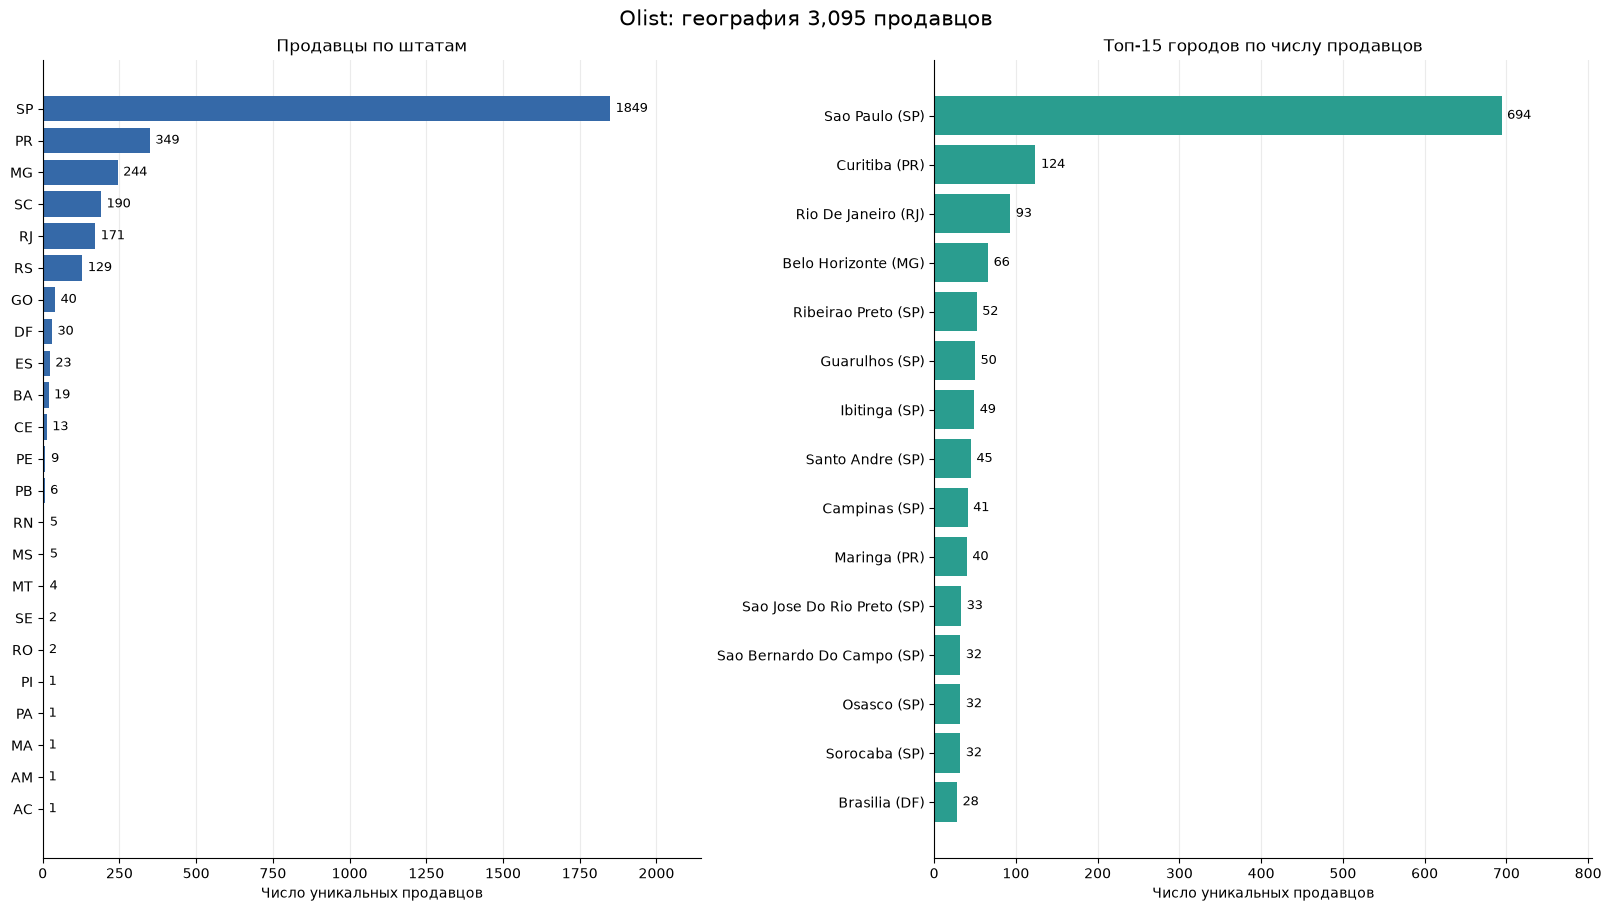

In [10]:
# География продавцов: каждая строка sellers — один продавец.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

seller_state_counts = sellers.groupby("seller_state")["seller_id"].nunique()
seller_state_counts = seller_state_counts.sort_values()
seller_city_counts = (
    sellers.groupby(["seller_city", "seller_state"])["seller_id"]
    .nunique().nlargest(15).sort_values()
)
# Штат в подписи позволяет различать одноимённые города.
city_labels = [f"{city.title()} ({state})" for city, state in seller_city_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 9), layout="constrained")
for ax, counts, labels, title, color in [
    (axes[0], seller_state_counts, seller_state_counts.index,
     "Продавцы по штатам", "#3569a8"),
    (axes[1], seller_city_counts, city_labels,
     "Топ-15 городов по числу продавцов", "#2a9d8f"),
]:
    bars = ax.barh(labels, counts.to_numpy(), color=color)
    ax.bar_label(bars, padding=4, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Число уникальных продавцов")
    ax.set_xlim(0, counts.max() * 1.16)
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Olist: география {sellers['seller_id'].nunique():,} продавцов", fontsize=15)
plt.show()

### Ассортимент и число продавцов одного товара

Используем позиции заказов из `order_items`, связанные с `sellers` по `seller_id`. Считаем уникальные пары **товар–продавец**, поэтому повторные продажи не увеличивают размер ассортимента. Это ассортимент, наблюдаемый в заказах датасета.

На правом графике ось числа товаров логарифмическая: иначе редкие товары с несколькими продавцами почти не видны. Над столбцами указаны точные количества.

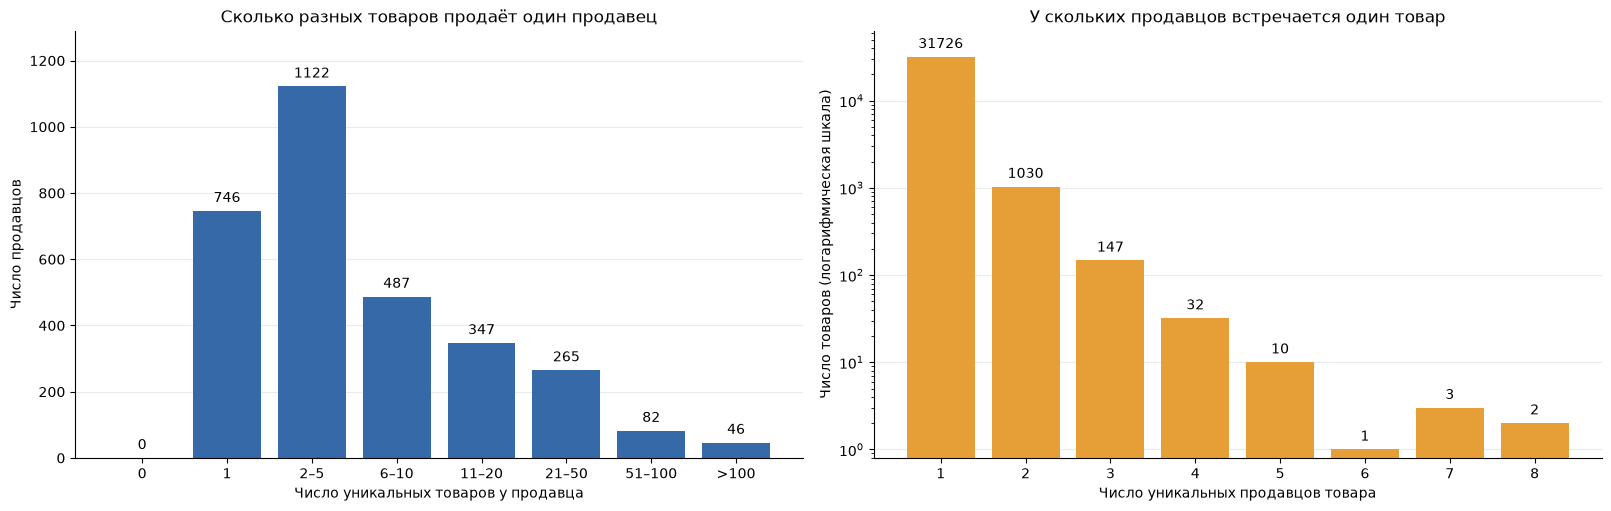

Продавцов с несколькими товарами: 2,349
Товаров с несколькими продавцами: 1,225
Каталог по product_id: 32,951; по паре товар–продавец: 34,448. Прирост: 1,497 (4.54%).


In [11]:
seller_order_items = order_items.merge(
    sellers[["seller_id"]], on="seller_id", how="left",
    validate="many_to_one", indicator=True,
)
assert seller_order_items["_merge"].eq("both").all(), "Есть позиции без продавца в sellers"
seller_order_items = seller_order_items.drop(columns="_merge")
product_seller_pairs = seller_order_items[["product_id", "seller_id"]].drop_duplicates()
products_per_seller = (
    product_seller_pairs.groupby("seller_id").size()
    .reindex(sellers["seller_id"], fill_value=0)
)
sellers_per_product = product_seller_pairs.groupby("product_id").size()

assortment_groups = pd.cut(
    products_per_seller,
    bins=[-1, 0, 1, 5, 10, 20, 50, 100, np.inf],
    labels=["0", "1", "2–5", "6–10", "11–20", "21–50", "51–100", ">100"],
)
assortment_counts = assortment_groups.value_counts(sort=False)
seller_count_distribution = sellers_per_product.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), layout="constrained")
bars = axes[0].bar(assortment_counts.index.astype(str), assortment_counts, color="#3569a8")
axes[0].bar_label(bars, padding=4)
axes[0].set_title("Сколько разных товаров продаёт один продавец")
axes[0].set_xlabel("Число уникальных товаров у продавца")
axes[0].set_ylabel("Число продавцов")
axes[0].set_ylim(0, assortment_counts.max() * 1.15)

bars = axes[1].bar(
    seller_count_distribution.index.astype(str), seller_count_distribution, color="#e69f36"
)
axes[1].bar_label(bars, padding=4)
axes[1].set_yscale("log")
axes[1].set_ylim(0.8, seller_count_distribution.max() * 2)
axes[1].set_title("У скольких продавцов встречается один товар")
axes[1].set_xlabel("Число уникальных продавцов товара")
axes[1].set_ylabel("Число товаров (логарифмическая шкала)")
for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

n_products = len(sellers_per_product)
n_offers = len(product_seller_pairs)
print(f"Продавцов с несколькими товарами: {products_per_seller.gt(1).sum():,}")
print(f"Товаров с несколькими продавцами: {sellers_per_product.gt(1).sum():,}")
print(
    f"Каталог по product_id: {n_products:,}; по паре товар–продавец: {n_offers:,}. "
    f"Прирост: {n_offers - n_products:,} ({n_offers / n_products - 1:.2%})."
)


### Различия цен и доставки у продавцов одного товара

Для каждой пары `product_id`–`seller_id` берём медианные `price` и `freight_value` по всем её позициям заказов. Затем для каждого товара с **двумя и более продавцами** считаем размах: максимальная медиана среди продавцов минус минимальная. Все такие товары имеют одинаковый вес на графике.

Кривая показывает долю товаров, у которых размах не превышает значение на горизонтальной оси. Например, отметка 50% соответствует медианному размаху. Нулевые различия тоже включены; шкала X линейна до 1 BRL и логарифмическая далее, чтобы показать и малые различия, и большие выбросы.

Суммы указаны в бразильских реалах (BRL). Сравнение описательное: на цену влияет время покупки, на доставку — в том числе адрес покупателя.

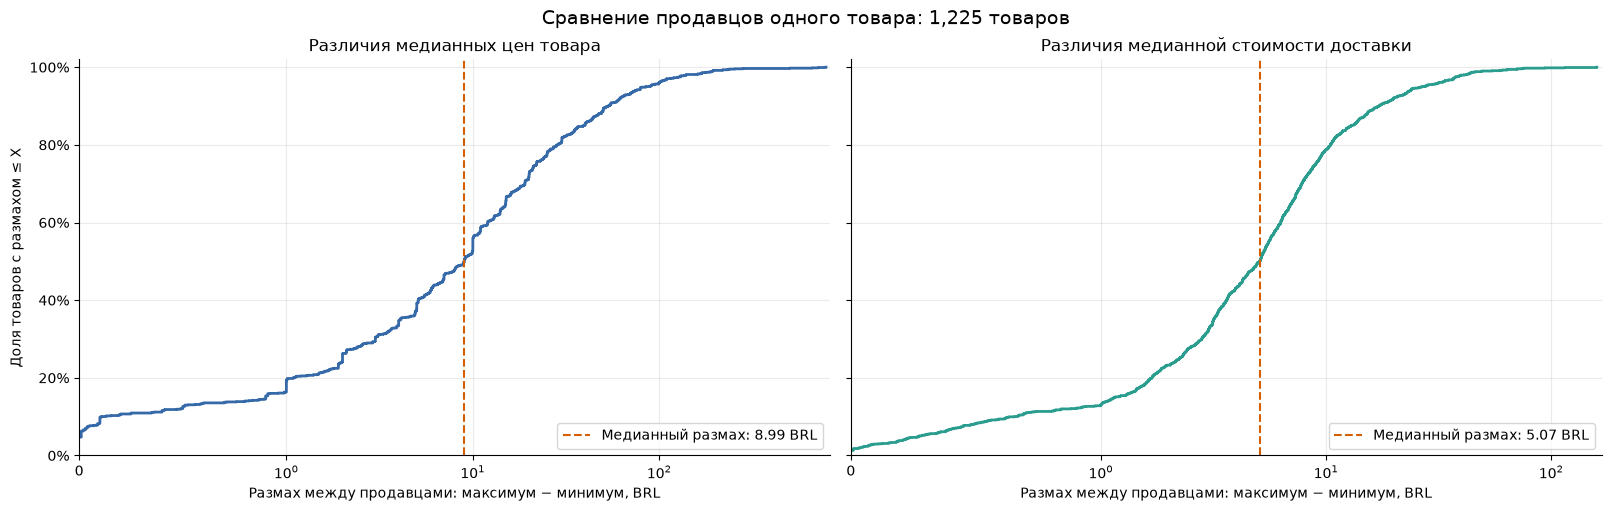

In [12]:
seller_product_prices = (
    seller_order_items.groupby(["product_id", "seller_id"])[["price", "freight_value"]]
    .median()
)
product_price_ranges = seller_product_prices.groupby("product_id").agg(
    seller_count=("price", "size"),
    price_min=("price", "min"), price_max=("price", "max"),
    freight_min=("freight_value", "min"), freight_max=("freight_value", "max"),
)
product_price_ranges = product_price_ranges.loc[
    product_price_ranges["seller_count"].ge(2)
].copy()
product_price_ranges["price_spread"] = (
    product_price_ranges["price_max"] - product_price_ranges["price_min"]
)
product_price_ranges["freight_spread"] = (
    product_price_ranges["freight_max"] - product_price_ranges["freight_min"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, layout="constrained")
for ax, column, title, color in [
    (axes[0], "price_spread", "Различия медианных цен товара", "#3569a8"),
    (axes[1], "freight_spread", "Различия медианной стоимости доставки", "#2a9d8f"),
]:
    values = product_price_ranges[column].sort_values().to_numpy()
    # Уникальные X корректно объединяют товары с одинаковым размахом.
    thresholds, counts = np.unique(values, return_counts=True)
    shares = np.cumsum(counts) / len(values)
    ax.step(thresholds, shares, where="post", color=color, linewidth=2)
    median_spread = np.median(values)
    ax.axvline(
        median_spread, color="#d55e00", linestyle="--",
        label=f"Медианный размах: {median_spread:.2f} BRL",
    )
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.set_xlabel("Размах между продавцами: максимум − минимум, BRL")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower right")
axes[0].set_ylabel("Доля товаров с размахом ≤ X")
fig.suptitle(
    f"Сравнение продавцов одного товара: {len(product_price_ranges):,} товаров", fontsize=14
)
plt.show()

In [13]:
# Переводы названий категорий
category_translation = pd.read_csv(DATASET_DIR / "product_category_name_translation.csv")
category_translation.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


## Сборка единого датасета

Реализуем решения из новых комментариев после линий подчёркивания. **Одна строка — одна позиция заказа**, ключ — `(order_id, order_item_id)`. В заказе может быть несколько товаров; каждый сохраняет собственные признаки, цену и расположение продавца. Повторные единицы одного товара не удаляем.

| Источник | Что попадает в результат |
| --- | --- |
| Заказы | Все столбцы, только статус `delivered`. Даты преобразуем в `datetime`. |
| Позиции заказов | Все столбцы, кроме `shipping_limit_date` и итогового `seller_id`. Удаляем все позиции товаров, у которых более одного продавца **во всём исходном `order_items`**, до фильтра по статусу. Другие позиции того же заказа сохраняем. |
| Покупатели | Все столбцы, включая `customer_id`, `customer_unique_id`, индекс, город и штат. |
| Продавцы | Индекс, город, штат; `seller_id` используем только при соединении. |
| Геолокация | `customer_geolocation_lat/lng/city/state` для получателя и `seller_geolocation_lat/lng/city/state` для отправителя. По индексу берём медианы координат и наиболее частую пару город–штат; при равенстве частот — первую по алфавиту. Это расположение почтового префикса, а не точный адрес. |
| Товары | Все столбцы; `product_category_name` заменяем английским переводом, при отсутствии перевода оставляем оригинал. Исходный пропуск остаётся пропуском. |
| Отзывы | По последнему решению все поля отзывов исключены: идентификаторы, оценки, тексты, даты, счётчики слов и количества отзывов заказа и товара. |

Платежи не присоединяем, согласно комментарию к этой таблице. Почтовые префиксы приводим к строкам из пяти цифр. Соединения справочников выполняем с `validate="many_to_one"`; отсутствующие сведения сохраняем как пропуски.

Это ретроспективная таблица: итоговый статус и фактические даты доставки описывают результат покупки. При дальнейшем выборе признаков для рекомендации на момент покупки их нужно отделить от доступных тогда данных.

Исходные таблицы выше используются для исследования; сборка ниже работает с копиями и сохраняет результат в `dataset/olist_prepared_dataset.csv`.

In [14]:
from IPython.display import display

ROW_KEY = ["order_id", "order_item_id"]
assert not order_items[ROW_KEY].isna().any().any()
assert not order_items.duplicated(ROW_KEY).any()
assert orders["order_id"].is_unique
assert order_items["order_id"].isin(orders["order_id"]).all()

delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
order_date_columns = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for column in order_date_columns:
    delivered_orders[column] = pd.to_datetime(delivered_orders[column], errors="raise")

# Считаем по всем исходным продажам: фильтр delivered не должен скрыть второго продавца.
source_seller_counts = order_items.groupby("product_id")["seller_id"].nunique()
single_seller_products = source_seller_counts.index[source_seller_counts.eq(1)]
delivered_items = order_items.drop(columns="shipping_limit_date").merge(
    delivered_orders, on="order_id", how="inner", validate="many_to_one",
)
selected_items = delivered_items.loc[
    delivered_items["product_id"].isin(single_seller_products)
].copy()

filter_summary = pd.DataFrame([
    {"stage": stage, "rows": len(frame),
     "orders": frame["order_id"].nunique(), "products": frame["product_id"].nunique()}
    for stage, frame in [
        ("Исходные позиции", order_items),
        ("Только delivered", delivered_items),
        ("Товары с одним продавцом", selected_items),
    ]
]).set_index("stage")
print(f"Исключено заказов не delivered: {len(orders) - len(delivered_orders):,}")
print(f"Товаров с несколькими продавцами в источнике: {source_seller_counts.gt(1).sum():,}")
display(filter_summary)

Исключено заказов не delivered: 2,963
Товаров с несколькими продавцами в источнике: 1,225


,rows,orders,products
stage,,,
Исходные позиции,112650,98666,32951
Только delivered,110197,96478,32216
Товары с одним продавцом,96068,84130,30991


In [15]:
customer_features = customers.copy()
seller_features = sellers.copy()
geo_source = geolocation.copy()
for frame, column in [
    (customer_features, "customer_zip_code_prefix"),
    (seller_features, "seller_zip_code_prefix"),
    (geo_source, "geolocation_zip_code_prefix"),
]:
    frame[column] = frame[column].astype("string").str.zfill(5)
    assert frame[column].dropna().str.fullmatch(r"[0-9]{5}").all()

geo_key = "geolocation_zip_code_prefix"
geo_source = geo_source.loc[geo_source[geo_key].notna()]
geo_coordinates = geo_source.groupby(geo_key, as_index=False).agg(
    geolocation_lat=("geolocation_lat", "median"),
    geolocation_lng=("geolocation_lng", "median"),
)
# Выбираем город и штат вместе, чтобы не получить несуществующую пару.
geo_places = (
    geo_source.groupby(
        [geo_key, "geolocation_city", "geolocation_state"], dropna=False,
    ).size().rename("point_count").reset_index()
    .sort_values(
        [geo_key, "point_count", "geolocation_city", "geolocation_state"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates(geo_key)
    .drop(columns="point_count")
)
geo_by_zip = geo_coordinates.merge(
    geo_places, on=geo_key, how="left", validate="one_to_one",
)
customer_geo = geo_by_zip.rename(columns={
    column: "customer_zip_code_prefix" if column == geo_key else f"customer_{column}"
    for column in geo_by_zip.columns
})
seller_geo = geo_by_zip.rename(columns={
    column: "seller_zip_code_prefix" if column == geo_key else f"seller_{column}"
    for column in geo_by_zip.columns
})
customer_features = customer_features.merge(
    customer_geo, on="customer_zip_code_prefix", how="left", validate="many_to_one",
)
seller_features = seller_features.merge(
    seller_geo, on="seller_zip_code_prefix", how="left", validate="many_to_one",
)
print(f"Геолокация: {len(geolocation):,} точек → {len(geo_by_zip):,} почтовых префиксов")

Геолокация: 1,000,163 точек → 19,015 почтовых префиксов


In [16]:
assert category_translation["product_category_name"].is_unique
category_map = category_translation.set_index("product_category_name")[
    "product_category_name_english"
]
product_features = products.copy()
translated_categories = product_features["product_category_name"].map(category_map)
product_features["product_category_name"] = translated_categories.fillna(
    product_features["product_category_name"]
)
untranslated_categories = products.loc[
    products["product_category_name"].notna() & translated_categories.isna(),
    "product_category_name",
].unique()
print("Категории, оставленные в оригинале:", sorted(untranslated_categories))

Категории, оставленные в оригинале: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']


In [17]:
assert selected_items["customer_id"].isin(customer_features["customer_id"]).all()
assert selected_items["seller_id"].isin(seller_features["seller_id"]).all()
assert selected_items["product_id"].isin(product_features["product_id"]).all()

prepared_dataset = (
    selected_items
    .merge(customer_features, on="customer_id", how="left", validate="many_to_one")
    .merge(seller_features, on="seller_id", how="left", validate="many_to_one")
    .merge(product_features, on="product_id", how="left", validate="many_to_one")
    .drop(columns="seller_id")
    .sort_values(["order_purchase_timestamp", *ROW_KEY])
    .reset_index(drop=True)
)

id_columns = [*ROW_KEY, "customer_id", "customer_unique_id", "product_id"]
prepared_dataset = prepared_dataset[
    id_columns + [column for column in prepared_dataset.columns if column not in id_columns]
]

# Проверяем точное сохранение набора позиций после всех присоединений.
assert len(prepared_dataset) == len(selected_items)
assert not prepared_dataset.duplicated(ROW_KEY).any()
assert not prepared_dataset[id_columns].isna().any().any()
pd.testing.assert_frame_equal(
    prepared_dataset[ROW_KEY].sort_values(ROW_KEY).reset_index(drop=True),
    selected_items[ROW_KEY].sort_values(ROW_KEY).reset_index(drop=True),
)
assert prepared_dataset.columns.is_unique
assert prepared_dataset["order_status"].eq("delivered").all()
assert prepared_dataset["product_id"].map(source_seller_counts).eq(1).all()
assert not {"seller_id", "shipping_limit_date"}.intersection(prepared_dataset.columns)
assert not prepared_dataset.columns.str.contains("review", case=False).any()
assert len(prepared_dataset) >= 10_000
assert prepared_dataset.shape[1] - len(id_columns) >= 10
assert prepared_dataset[["customer_state", "product_category_name"]].nunique().gt(1).all()
assert prepared_dataset["order_purchase_timestamp"].notna().all()
assert prepared_dataset.isna().any().any()

print(f"Итог: {len(prepared_dataset):,} строк × {prepared_dataset.shape[1]} столбцов")
print(f"Заказов: {prepared_dataset['order_id'].nunique():,}")
print(f"Покупателей: {prepared_dataset['customer_unique_id'].nunique():,}")
print(f"Товаров: {prepared_dataset['product_id'].nunique():,}")
with pd.option_context("display.max_columns", None):
    display(prepared_dataset.head())

Итог: 96,068 строк × 35 столбцов
Заказов: 84,130
Покупателей: 81,541
Товаров: 30,991


,order_id,order_item_id,customer_id,customer_unique_id,product_id,price,freight_value,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,customer_geolocation_lat,customer_geolocation_lng,customer_geolocation_city,customer_geolocation_state,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng,seller_geolocation_city,seller_geolocation_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,bfbd0f9bdef84302105ad712db648a6c,1,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,14600,sao joaquim da barra,SP,-20.585396,-47.863156,sao joaquim da barra,SP,81810,curitiba,PR,-25.507138,-49.276529,curitiba,PR,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0
1,bfbd0f9bdef84302105ad712db648a6c,2,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,14600,sao joaquim da barra,SP,-20.585396,-47.863156,sao joaquim da barra,SP,81810,curitiba,PR,-25.507138,-49.276529,curitiba,PR,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0
2,bfbd0f9bdef84302105ad712db648a6c,3,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,14600,sao joaquim da barra,SP,-20.585396,-47.863156,sao joaquim da barra,SP,81810,curitiba,PR,-25.507138,-49.276529,curitiba,PR,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0
3,3b697a20d9e427646d92567910af6d57,1,355077684019f7f60a031656bd7262b8,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,29.90,15.56,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,04106,sao paulo,SP,-23.581321,-46.635726,sao paulo,SP,85801,cascavel,PR,-24.958205,-53.461305,cascavel,PR,watches_gifts,63.0,1642.0,3.0,300.0,16.0,16.0,16.0
4,be5bc2f0da14d8071e2d45451ad119d9,1,7ec40b22510fdbea1b08921dd39e63d8,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,21.90,17.19,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,98280,panambi,RS,-28.291275,-53.501401,panambi,RS,15802,catanduva,SP,-21.142974,-48.994517,catanduva,SP,sports_leisure,39.0,518.0,1.0,400.0,16.0,16.0,16.0


In [18]:
# Полный список итоговых колонок, их типов и пропусков.
dataset_schema = pd.DataFrame({
    "dtype": prepared_dataset.dtypes.astype(str),
    "missing_count": prepared_dataset.isna().sum(),
    "missing_percent": prepared_dataset.isna().mean().mul(100).round(2),
    "unique_count": prepared_dataset.nunique(),
}).rename_axis("column")
with pd.option_context("display.max_rows", None):
    display(dataset_schema)

,dtype,missing_count,missing_percent,unique_count
column,,,,
order_id,str,0,0.00,84130
order_item_id,int64,0,0.00,21
customer_id,str,0,0.00,84130
customer_unique_id,str,0,0.00,81541
product_id,str,0,0.00,30991
price,float64,0,0.00,5390
freight_value,float64,0,0.00,6709
order_status,str,0,0.00,1
order_purchase_timestamp,datetime64[us],0,0.00,83702


### Сохранение и проверка загрузки

Сохраняем CSV в UTF-8 без индекса DataFrame. При повторном выполнении файл пересоздаётся из исходных таблиц. CSV не хранит типы: при чтении задаём типы столбцов и список дат явно, в том числе строковые типы почтовых префиксов. Проверяем полное совпадение загруженной таблицы с `prepared_dataset`, включая значения, пропуски, порядок и типы столбцов.

In [19]:
OUTPUT_PATH = DATASET_DIR / "olist_prepared_dataset.csv"
prepared_dataset.to_csv(
    OUTPUT_PATH, index=False, encoding="utf-8", date_format="%Y-%m-%d %H:%M:%S",
)

datetime_columns = order_date_columns
csv_dtypes = {
    column: str(dtype) for column, dtype in prepared_dataset.dtypes.items()
    if column not in datetime_columns
}
saved_dataset = pd.read_csv(
    OUTPUT_PATH, encoding="utf-8", encoding_errors="strict",
    dtype=csv_dtypes, parse_dates=datetime_columns, float_precision="round_trip",
).astype(prepared_dataset.dtypes.to_dict())
pd.testing.assert_frame_equal(prepared_dataset, saved_dataset, check_exact=True)
print(f"Сохранено: {OUTPUT_PATH.resolve()}")
print(f"Размер файла: {OUTPUT_PATH.stat().st_size / 1024**2:.1f} МиБ")
print("Повторная загрузка CSV: все значения и типы совпадают.")

Сохранено: /home/user/prak/dataset/olist_prepared_dataset.csv
Размер файла: 41.3 МиБ
Повторная загрузка CSV: все значения и типы совпадают.
